# 📡 TP Télécom 3GPP — Phase 1 : Comparaison de 3 LLMs Open Source

**Version CPU — Modèles locaux (sans GPU)**

| Modèle | Taille | Fournisseur |
|--------|--------|-------------|
| DistilGPT2 | 82M | DistilBERT / HuggingFace |
| GPT2-Small | 117M | OpenAI |
| GPT2-Medium | 345M | OpenAI |

> 💡 **Mode CPU** : Modèles légers tournant entièrement en local sans GPU ni internet.
**Pipeline global :**
```
Phase 1 → Phase 2 → Phase 3 → Phase 4 → Phase 5 → Phase 6 → Phase 7
 [Ici]    LLM+RAG  RAG Avancé  Fine-Tune   RAFT    RAG+Agent  Multi-Agent
```

## 1. Installation des dépendances

In [1]:
!pip install -q huggingface_hub requests
!pip install -q datasets evaluate rouge_score bert_score
!pip install -q pandas matplotlib seaborn
print('✅ Installation terminée')

✅ Installation terminée


## 2. Configuration — Token Hugging Face

In [ ]:
import requests, time, json, os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

HF_TOKEN = "hf_XXXXXXXXXXXXXXXXXXXX"

HEADERS = {
    'Authorization': f'Bearer {HF_TOKEN}',
    'Content-Type': 'application/json'
}

# Vérification du token (CORRIGÉ)
test = requests.get(
    'https://huggingface.co/api/whoami-v2',
    headers=HEADERS
)

if test.status_code == 200:
    print(f'✅ Token valide — connecté en tant que : {test.json()["name"]}')
else:
    print('❌ Token invalide — vérifiez votre token sur https://huggingface.co/settings/tokens')
    print(test.status_code)
    print(test.text)

✅ Token valide — connecté en tant que : helen-faye-123


## 3. Définition des Modèles & Fonction d'Appel API

In [4]:
from transformers import pipeline
import time

# Modèles très légers — compatibles CPU et text-generation
MODELS = {
    'DistilGPT2'  : 'distilbert/distilgpt2',
    'GPT2-Small'  : 'openai-community/gpt2',
    'GPT2-Medium' : 'openai-community/gpt2-medium'
}

def format_prompt(model_name, question):
    return (f'3GPP Expert Answer — '
            f'Question: {question} '
            f'Answer:')

print('🔄 Loading models locally...')
pipelines = {}
for name, model_id in MODELS.items():
    print(f'  → Loading {name}...')
    pipelines[name] = pipeline(
        'text-generation',
        model=model_id
    )
    print(f'  ✅ {name} ready')

def call_local_model(model_name, question, max_new_tokens=100):
    prompt = format_prompt(model_name, question)
    t0 = time.time()
    result = pipelines[model_name](
        prompt,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=50256,
        truncation=True
    )
    elapsed = time.time() - t0
    full_text = result[0]['generated_text']
    answer = full_text.replace(prompt, '').strip()
    return answer, elapsed

print('\n✅ All models loaded and ready!')

🔄 Loading models locally...
  → Loading DistilGPT2...


Loading weights: 100%|██████████| 76/76 [00:00<00:00, 4223.03it/s]


  ✅ DistilGPT2 ready
  → Loading GPT2-Small...


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1304.65it/s]


  ✅ GPT2-Small ready
  → Loading GPT2-Medium...


Loading weights: 100%|██████████| 292/292 [00:00<00:00, 1103.55it/s]


  ✅ GPT2-Medium ready

✅ All models loaded and ready!


## 4. Chargement du Dataset 3GPP

In [5]:
import json

# -------------------------------------------------------
# 🔧 Mets ici le chemin de ton dossier archive
# -------------------------------------------------------
TRAIN_PATH = r"C:\Users\HP\Downloads\archive (1)\TeleQnA_training (1).txt"
TEST_PATH  = r"C:\Users\HP\Downloads\archive (1)\TeleQnA_testing1 (1).txt"

# Chargement du fichier d'entraînement
with open(TRAIN_PATH, 'r', encoding='utf-8') as f:
    train_data = json.load(f)

# Chargement du fichier de test
with open(TEST_PATH, 'r', encoding='utf-8') as f:
    test_data = json.load(f)

# Conversion en paires QA pour le notebook
qa_pairs = []
for i, (key, item) in enumerate(train_data.items()):
    qa_pairs.append({
        'id'              : i + 1,
        'question'        : item['question'],
        'reference_answer': item['answer'] + '. ' + item.get('explanation', ''),
        'context'         : item.get('category', '3GPP'),
        'options'         : {
            'option 1': item.get('option 1', ''),
            'option 2': item.get('option 2', ''),
            'option 3': item.get('option 3', ''),
            'option 4': item.get('option 4', '')
        }
    })

# On utilise les 10 premières pour la Phase 1
# (toutes les 1461 pour les phases suivantes)
qa_pairs_phase1 = qa_pairs[:10]

df_dataset = pd.DataFrame(qa_pairs_phase1)
print(f'✅ Dataset chargé :')
print(f'   Training : {len(train_data)} questions')
print(f'   Testing  : {len(test_data)} questions')
print(f'   Utilisées pour Phase 1 : {len(qa_pairs_phase1)} questions')
print(f'\n📊 Aperçu :')
for _, row in df_dataset.head(3).iterrows():
    print(f"\n  Q{row['id']} : {row['question'][:80]}...")
    print(f"  Réponse : {row['reference_answer'][:80]}...")
    print(f"  Catégorie : {row['context']}")

✅ Dataset chargé :
   Training : 1461 questions
   Testing  : 366 questions
   Utilisées pour Phase 1 : 10 questions

📊 Aperçu :

  Q1 : What is the purpose of the Nmfaf_3daDataManagement_Deconfigure service operation...
  Réponse : option 2: To configure the MFAF to stop mapping data or analytics received by th...
  Catégorie : Standards specifications

  Q2 : How does a supporting UE attach to the same core network operator from which it ...
  Réponse : option 2: It uses information stored in the UE when it was detached.. A supporti...
  Catégorie : Standards specifications

  Q3 : When can the setting of the Privacy exception list be changed? [3GPP Release 17]...
  Réponse : option 3: Anytime. The setting of the Privacy exception list can be changed anyt...
  Catégorie : Standards specifications


## 5. Inférence sur les 3 Modèles via API

In [7]:
import time
results = []

for model_name in MODELS.keys():
    print(f'\n{"="*60}')
    print(f'🤖 MODEL : {model_name}')
    print('='*60)

    for _, row in df_dataset.iterrows():
        print(f'  → Question {row["id"]} : {row["question"][:55]}...')
        answer, elapsed = call_local_model(model_name, row['question'])

        results.append({
            'model'           : model_name,
            'question_id'     : row['id'],
            'question'        : row['question'],
            'reference'       : row['reference_answer'],
            'generated'       : answer,
            'inference_time_s': round(elapsed, 2)
        })
        print(f'     ✓ Answer: {answer[:80]}...')
        print(f'     ⏱️  Time: {elapsed:.2f}s')

df_results = pd.DataFrame(results)
df_results.to_csv('phase1_raw_results.csv', index=False)
print(f'\n✅ Done — {len(df_results)} results saved to phase1_raw_results.csv')

[transformers] Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



🤖 MODEL : DistilGPT2
  → Question 1 : What is the purpose of the Nmfaf_3daDataManagement_Deco...


[transformers] Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


     ✓ Answer: What is the purpose of the Nmfaf_3daDataManagement_Deconfigure service operation...
     ⏱️  Time: 6.99s
  → Question 2 : How does a supporting UE attach to the same core networ...


[transformers] Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

     ✓ Answer: The WLAN Direct Discovery feature is designed to provide a direct connection bet...
     ⏱️  Time: 29.70s
  → Question 8 : When can there be two N3 tunnel terminations at the RAN...


[transformers] Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


     ✓ Answer: The RAN has determined that there are no two N3 tunnel terminations at the RAN f...
     ⏱️  Time: 39.00s
  → Question 9 : Which NGAP procedure is used for inter-system load bala...


[transformers] Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


     ✓ Answer: The inter-system load balancing (ISL) protocol is used for inter-system load bal...
     ⏱️  Time: 43.08s
  → Question 10 : What is the purpose of the Validity Period for predicti...
     ✓ Answer: The Validity Period is a period of time during which the Validity Period is not ...
     ⏱️  Time: 35.94s

✅ Done — 30 results saved to phase1_raw_results.csv


## 6. Aperçu des Réponses Générées

In [8]:
# Affichage comparatif pour une question
QUESTION_ID = 1
row_ref = df_dataset[df_dataset['id'] == QUESTION_ID].iloc[0]

print(f'❓ Question : {row_ref["question"]}')
print(f'📚 Source   : {row_ref["context"]}')
print(f'\n✅ Référence :\n{row_ref["reference_answer"]}')
print('\n' + '='*65)

for model_name in MODELS.keys():
    row = df_results[
        (df_results['model'] == model_name) &
        (df_results['question_id'] == QUESTION_ID)
    ].iloc[0]
    print(f'\n🤖 {model_name} ({row["inference_time_s"]}s) :')
    print(row['generated'][:400])
    print('-'*65)

❓ Question : What is the purpose of the Nmfaf_3daDataManagement_Deconfigure service operation? [3GPP Release 18]
📚 Source   : Standards specifications

✅ Référence :
option 2: To configure the MFAF to stop mapping data or analytics received by the MFAF to out-bound notification endpoints. The Nmfaf_3daDataManagement_Deconfigure service operation is used to stop mapping data or analytics received by the MFAF to one or more out-bound notification endpoints.


🤖 DistilGPT2 (6.99s) :
What is the purpose of the Nmfaf_3daDataManagement_Deconfigure service operation? [3GPP Release 18] Answer: What is the purpose of the Nmfaf_3daDataManagement_Deconfigure service operation? [3GPP Release 18] Answer: What is the purpose of the Nmfaf_3daDataManagement_Deconfigure service operation? [3GPP Release 18] Answer: What is the purpose of the N
-----------------------------------------------------------------

🤖 GPT2-Small (9.87s) :
The Nmfaf_3daDataManagement_Deconfigure service operation is a service t

## 7. Évaluation Automatique — ROUGE 

In [9]:
from evaluate import load as load_metric

# ROUGE uniquement (BERTScore trop lent sur CPU)
rouge = load_metric('rouge')

eval_results = []

for model_name in MODELS.keys():
    subset      = df_results[df_results['model'] == model_name]
    predictions = subset['generated'].tolist()
    references  = subset['reference'].tolist()

    rouge_scores = rouge.compute(
        predictions=predictions,
        references=references
    )
    avg_time = subset['inference_time_s'].mean()

    eval_results.append({
        'Modèle'        : model_name,
        'ROUGE-1'       : round(rouge_scores['rouge1'], 4),
        'ROUGE-2'       : round(rouge_scores['rouge2'], 4),
        'ROUGE-L'       : round(rouge_scores['rougeL'], 4),
        'Temps moy. (s)': round(avg_time, 2)
    })
    print(f'✅ {model_name} évalué')

df_eval = pd.DataFrame(eval_results)
print('\n📊 Tableau comparatif :')
print(df_eval.to_string(index=False))
df_eval.to_csv('phase1_evaluation.csv', index=False)
print('\n💾 Sauvegardé → phase1_evaluation.csv')

✅ DistilGPT2 évalué
✅ GPT2-Small évalué
✅ GPT2-Medium évalué

📊 Tableau comparatif :
     Modèle  ROUGE-1  ROUGE-2  ROUGE-L  Temps moy. (s)
 DistilGPT2   0.2590   0.1299   0.2451            5.91
 GPT2-Small   0.2216   0.0950   0.2100           12.57
GPT2-Medium   0.2474   0.1090   0.2232           32.09

💾 Sauvegardé → phase1_evaluation.csv


## 8. Visualisations Comparatives

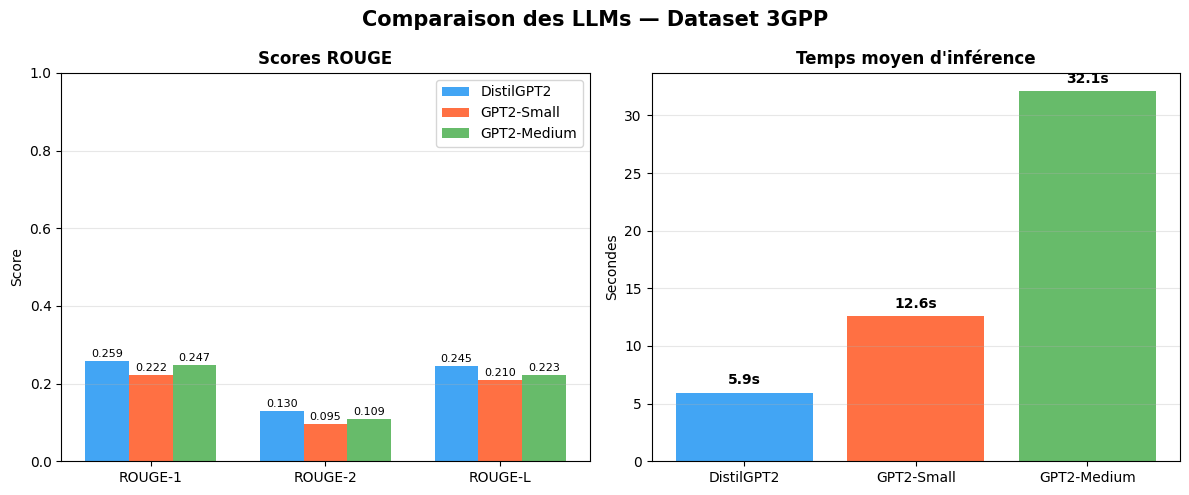

💾 Graphique → phase1_comparaison_llms.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Comparaison des LLMs — Dataset 3GPP', fontsize=15, fontweight='bold')
palette = ['#2196F3', '#FF5722', '#4CAF50']

# --- ROUGE scores ---
ax1 = axes[0]
metrics_r = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
x, w = range(len(metrics_r)), 0.25
for i, (_, row) in enumerate(df_eval.iterrows()):
    bars = ax1.bar([p + i*w for p in x], [row[m] for m in metrics_r],
                   width=w, label=row['Modèle'], color=palette[i], alpha=0.85)
    for b in bars:
        ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
                 f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=8)
ax1.set_xticks([p+w for p in x])
ax1.set_xticklabels(metrics_r)
ax1.set_ylim(0, 1)
ax1.set_title('Scores ROUGE', fontweight='bold')
ax1.set_ylabel('Score')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# --- Temps d'inférence ---
ax2 = axes[1]
bars = ax2.bar(df_eval['Modèle'], df_eval['Temps moy. (s)'], color=palette, alpha=0.85)
for b in bars:
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
             f'{b.get_height():.1f}s', ha='center', va='bottom',
             fontsize=10, fontweight='bold')
ax2.set_title('Temps moyen d\'inférence', fontweight='bold')
ax2.set_ylabel('Secondes')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('phase1_comparaison_llms.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Graphique → phase1_comparaison_llms.png')

## 9. Sélection du Meilleur Modèle

In [12]:
# Score composite : ROUGE-L (75%) + Vitesse (25%)
df_eval['Score_composite'] = (
    0.75 * df_eval['ROUGE-L'] +
    0.25 * (1 / df_eval['Temps moy. (s)'] /
            (1 / df_eval['Temps moy. (s)']).max())
).round(4)

df_sorted  = df_eval.sort_values('Score_composite', ascending=False)
best_model = df_sorted.iloc[0]['Modèle']
best_model_id = MODELS[best_model]

print('📊 Classement final :')
print(df_sorted[['Modèle','ROUGE-L','Temps moy. (s)','Score_composite']].to_string(index=False))
print(f'\n🏆 Meilleur modèle → {best_model}')

config = {
    'best_model_name' : best_model,
    'best_model_id'   : best_model_id,
    'phase1_complete' : True
}
with open('pipeline_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('💾 Config sauvegardée → pipeline_config.json')
print('\n➡️  Phase 1 terminée ! Passez au notebook Phase 2 — LLM + RAG')

📊 Classement final :
     Modèle  ROUGE-L  Temps moy. (s)  Score_composite
 DistilGPT2   0.2451            5.91           0.4338
 GPT2-Small   0.2100           12.57           0.2750
GPT2-Medium   0.2232           32.09           0.2134

🏆 Meilleur modèle → DistilGPT2
💾 Config sauvegardée → pipeline_config.json

➡️  Phase 1 terminée ! Passez au notebook Phase 2 — LLM + RAG


---
## ✅ Phase 1 Terminée

**Fichiers produits :**
- `phase1_raw_results.csv` — Toutes les réponses générées
- `phase1_evaluation.csv` — Scores ROUGE & BERTScore
- `phase1_comparaison_llms.png` — Graphiques comparatifs
- `pipeline_config.json` — Meilleur modèle transmis aux phases suivantes

**➡️ Prochaine étape : `Phase2_LLM_RAG_3GPP.ipynb`**